#### Step 1: Import Packages

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

#### Step 2: Load Data

In [108]:
iris = datasets.load_iris()
X, y = iris.data[50:, [1,2]], iris.target[50:]
le = LabelEncoder()
y = le.fit_transform(y)

In [109]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.5,
                                                    random_state=1,
                                                    stratify=y)

#### Step 3: Initialize Different Models

In [110]:
clf1 = LogisticRegression(l1_ratio=0,
                          C=0.0001,
                          solver='lbfgs',
                          random_state=1)

clf2 = DecisionTreeClassifier(max_depth=1,
                              criterion='entropy',
                              random_state=0)

clf3 = KNeighborsClassifier(n_neighbors=1,
                            p=2,
                            metric='minkowski')

#### Step 4: Create pipeline

In [111]:
pipe1 = Pipeline([
    ['sc', StandardScaler()],
     ['clf', clf1]
     ])
pipe2 = Pipeline([
    ['sc', StandardScaler()],
    ['clf', clf3]
])

clf_labels = ['Logistic Regression', 'Decision tree', 'KNN']

for clf, label in zip([pipe1, clf2, pipe2], clf_labels):
    scores = cross_val_score(clf,
                             X=X_train,
                             y=y_train,
                             cv=10,
                             n_jobs=-1,
                             scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.3f}, std: +/-{scores.std():.3f}, label: {label}')

ROC AUC: 0.917, std: +/-0.154, label: Logistic Regression
ROC AUC: 0.867, std: +/-0.183, label: Decision tree
ROC AUC: 0.850, std: +/-0.133, label: KNN


#### Step 5: VotingClassifier

In [113]:
mv_clf = VotingClassifier(
    estimators= [('lr', pipe1),
    ('dt', clf2),
    ('knn', pipe2)],
    voting='soft'
)

clf_labels += ['Majority voting']
all_clf = [pipe1, clf2, pipe2, mv_clf]

for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(clf,
                             X=X_train,
                             y=y_train,
                             cv=10,
                             n_jobs=-1,
                             scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.3f}, std: +/-{scores.std():.3f}, label: {label}')

ROC AUC: 0.917, std: +/-0.154, label: Logistic Regression
ROC AUC: 0.867, std: +/-0.183, label: Decision tree
ROC AUC: 0.850, std: +/-0.133, label: KNN
ROC AUC: 0.983, std: +/-0.050, label: Majority voting


#### Step 6: Evaluating the Ensemble classifer

In [114]:
from sklearn.metrics import auc, roc_curve

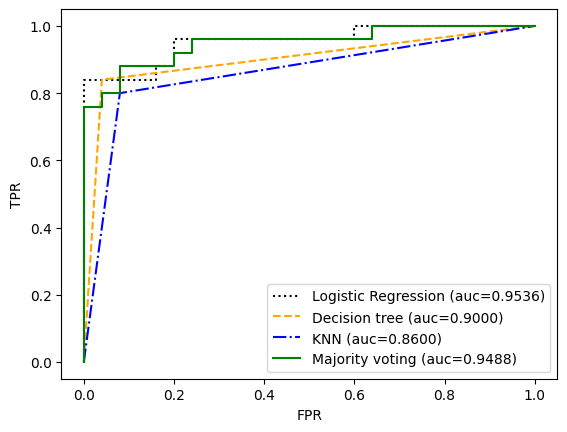

In [120]:
colors = ['black', 'orange','blue', 'green']
linestyles = [':','--','-.','-']

for clf, label, clr, ls in zip(all_clf, clf_labels, colors, linestyles):
    y_pred_prob = clf.fit(X_train, y_train).predict_proba(X_test)[:,1]
    fpr, tpr, threshold = roc_curve(y_test, y_pred_prob)

    roc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             color=clr,
             linestyle=ls,
             label=f'{label:s} (auc={roc_score:.4f})')
plt.legend(loc='best')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.show()

#### Step 7: Classification Boundary

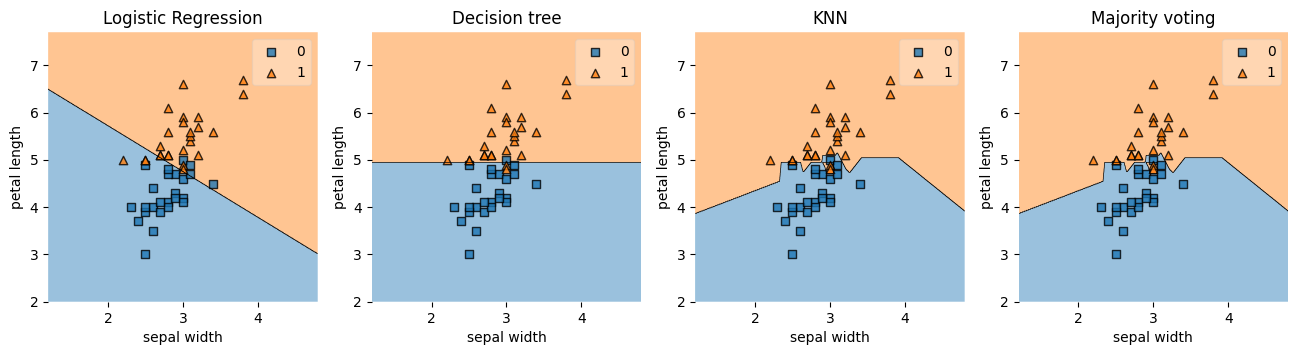

In [124]:
fig, axes = plt.subplots(1, 4, figsize=(16,3.5), sharey=True)

for i, (clf, label) in enumerate(zip(all_clf, clf_labels)):
    plot_decision_regions(X = X_train, y=y_train, clf=clf, ax=axes[i])
    axes[i].set_title(f'{label}')
    axes[i].set_ylabel('petal length')
    axes[i].set_xlabel('sepal width')

#### Step 8: Pruning - GridSearchCV

In [125]:
mv_clf.get_params()

{'estimators': [('lr',
   Pipeline(steps=[('sc', StandardScaler()),
                   ['clf',
                    LogisticRegression(C=0.0001, l1_ratio=0, random_state=1)]])),
  ('dt',
   DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0)),
  ('knn',
   Pipeline(steps=[('sc', StandardScaler()),
                   ['clf', KNeighborsClassifier(n_neighbors=1)]]))],
 'flatten_transform': True,
 'n_jobs': None,
 'verbose': False,
 'voting': 'soft',
 'weights': None,
 'lr': Pipeline(steps=[('sc', StandardScaler()),
                 ['clf',
                  LogisticRegression(C=0.0001, l1_ratio=0, random_state=1)]]),
 'dt': DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0),
 'knn': Pipeline(steps=[('sc', StandardScaler()),
                 ['clf', KNeighborsClassifier(n_neighbors=1)]]),
 'lr__memory': None,
 'lr__steps': [('sc', StandardScaler()),
  ['clf', LogisticRegression(C=0.0001, l1_ratio=0, random_state=1)]],
 'lr__transform_input': None,


In [127]:
params = {
    'dt__max_depth':[1,2],
    'lr__clf__C':[0.001, 0.1, 1.]
}

In [132]:
grid = GridSearchCV(estimator=mv_clf,
                    param_grid=params,
                    scoring='roc_auc',
                    n_jobs=-1,
                    cv=10)

In [134]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",VotingClassif...voting='soft')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'dt__max_depth': [1, 2], 'lr__clf__C': [0.001, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;

In [135]:
grid.cv_results_

{'mean_fit_time': array([0.00499537, 0.00453875, 0.00264413, 0.00233517, 0.00219221,
        0.00198638]),
 'std_fit_time': array([0.00139913, 0.00073936, 0.00031463, 0.00043522, 0.00054112,
        0.00029188]),
 'mean_score_time': array([0.00145876, 0.00183561, 0.00105462, 0.00099773, 0.00105169,
        0.00089006]),
 'std_score_time': array([0.00047316, 0.00070643, 0.0001236 , 0.00016593, 0.00013953,
        0.00016938]),
 'param_dt__max_depth': masked_array(data=[1, 1, 1, 2, 2, 2],
              mask=[False, False, False, False, False, False],
        fill_value=999999),
 'param_lr__clf__C': masked_array(data=[0.001, 0.1, 1.0, 0.001, 0.1, 1.0],
              mask=[False, False, False, False, False, False],
        fill_value=1e+20),
 'params': [{'dt__max_depth': 1, 'lr__clf__C': 0.001},
  {'dt__max_depth': 1, 'lr__clf__C': 0.1},
  {'dt__max_depth': 1, 'lr__clf__C': 1.0},
  {'dt__max_depth': 2, 'lr__clf__C': 0.001},
  {'dt__max_depth': 2, 'lr__clf__C': 0.1},
  {'dt__max_depth': 2, 

In [136]:
grid.best_params_

{'dt__max_depth': 1, 'lr__clf__C': 0.001}

In [137]:
grid.best_score_

np.float64(0.9833333333333334)

In [138]:
grid.best_estimator_

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('dt', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.001


In [139]:
grid.cv_results_['mean_test_score']

array([0.98333333, 0.98333333, 0.96666667, 0.98333333, 0.98333333,
       0.96666667])